# USA Real Estate Data Quality Audit — Part 1: Re-examining the "38.19% suspicious" headline

**Author:** Mariam Fathi · **Data:** [USA Real Estate Dataset](https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset) (2,226,382 realtor.com listings)

## Why this notebook exists

An earlier version of this series reported that **38.19% of listings were "suspicious"**, raising the possibility of
price manipulation or fraud. Before building anything on top of that number I audited the audit. This notebook
re-runs the original detectors, then asks of each flag: *what mechanism produces it?*

## Summary of findings

| # | Original claim | What the data shows |
|---|---|---|
| 1 | 734,297 "placeholder dates" (33.0%) | Every one is an ordinary missing value. `astype(str)` (pandas 2) turns `NaN` into the string `'nan'`, which was on the placeholder list. Missingness is **structural**: 0% for `sold`, 100% for `ready_to_build` (new builds were never sold). |
| 2 | 57,930 "same price, different dates" patterns (115,872 records) | 99.9% are one `for_sale` record + one `sold` record of the **same property** — the listing captured twice in its lifecycle. The "date span" is the gap between the prior sale and the 2021–22 sale (median 8.6 years), i.e. a normal holding period. |
| 3 | 66,960 "price manipulation" cases | The same `for_sale` + `sold` pairs (99.8%), found again with a different key. |
| 4 | A few brokers drive most suspicious patterns | The top 3 "suspicious" brokers are the 3 largest brokers by volume, flagged at the same rate (~8.5% of their sales). Flag counts track volume (Spearman ρ = 0.71). |
| 5 | (unreported) | The detector silently skipped 57,388 duplicated records because `groupby` drops groups with any missing key. |

**Corrected picture:** the dataset contains no evidence of fraud. It does contain a real data-quality issue that matters
for modelling: **10.4% of records belong to a property that appears more than once**, almost always as a `for_sale` /
`sold` pair. Those must be deduplicated before property-level analysis, or a model will see the same house in train
and test (investigated in a later part).

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

CANDIDATES = ['/kaggle/input/usa-real-estate-dataset/realtor-data.zip.csv',
              '../data/raw/realtor-data.zip.csv', 'data/raw/realtor-data.zip.csv']
PATH = next(p for p in CANDIDATES if os.path.exists(p))

raw = pd.read_csv(PATH)
df = raw.copy()
df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], format='%Y-%m-%d', errors='coerce')
N = len(df)
assert N == 2_226_382  # same snapshot the original notebooks used
print(f'{N:,} records, {df.shape[1]} columns')
df['status'].value_counts()

2,226,382 records, 12 columns


status
for_sale          1389306
sold               812009
ready_to_build      25067
Name: count, dtype: int64

In [2]:
# Chart style: one accent hue, recessive grid, no chart junk
BLUE, ORANGE, GRAY = '#2a78d6', '#eb6834', '#8a8984'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.grid': True, 'grid.color': '#ecebe7', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e', 'font.size': 10.5,
})

## 2. Reproduce the original numbers

The original detectors used Python loops over `groupby` groups. Below are vectorised re-implementations with **identical
logic** (including the `astype(str)` step and `groupby`'s default `dropna=True`). The asserts check that they
reproduce the published counts exactly, so everything after this point explains the *same* flags.

In [3]:
PROPERTY_KEY = ['brokered_by', 'price', 'bed', 'bath', 'acre_lot',
                'street', 'city', 'state', 'zip_code', 'house_size']   # original Phase 2 key
PLACEHOLDERS = ['####', '0000-00-00', '1900-01-01', 'nan', 'null', 'none',
                'missing', 'unknown', 'n/a', 'na']


def original_placeholder_dates(raw):
    # the original used astype(str), which in pandas 2 turns NaN into 'nan'; spelled out so pandas 3 agrees
    s = raw['prev_sold_date'].astype('string').fillna('nan').str.lower()
    return s.isin(PLACEHOLDERS) | s.str.contains('####', regex=False)


def date_span_flags(d, key):
    # groups (on `key`, NaN keys dropped) with >1 record, >1 dated record and a date span > 365 days
    g = d.dropna(subset=key)
    gid = g.groupby(key).ngroup()
    agg = g.groupby(gid).agg(n=('price', 'size'), nd=('prev_sold_date', 'count'),
                             dmin=('prev_sold_date', 'min'), dmax=('prev_sold_date', 'max'))
    keep = agg[(agg.n > 1) & (agg.nd > 1) & ((agg.dmax - agg.dmin).dt.days > 365)].index
    return g.assign(gid=gid)[gid.isin(keep)]


def original_same_price_different_dates(df):
    dup = df[df.duplicated(subset=PROPERTY_KEY, keep=False)]
    return date_span_flags(dup, PROPERTY_KEY)


def original_price_manipulation(df):
    # same physical property (5-column key), all dated records at one price, spanning > 365 days
    key = ['street', 'city', 'state', 'zip_code', 'house_size']
    g = df.dropna(subset=key)
    g = g.assign(gid=g.groupby(key).ngroup())
    g = g[g.groupby('gid')['price'].transform('size') > 1]
    dated = g[g.prev_sold_date.notna()]
    a = dated.groupby('gid').agg(nd=('price', 'size'), pmin=('price', 'min'), pmax=('price', 'max'),
                                 pna=('price', lambda s: s.isna().sum()),
                                 dmin=('prev_sold_date', 'min'), dmax=('prev_sold_date', 'max'))
    keep = a[(a.nd > 1) & (a.pmin == a.pmax) & (a.pna == 0) & ((a.dmax - a.dmin).dt.days > 365)].index
    return g[g.gid.isin(keep)]


placeholder = original_placeholder_dates(raw)
same_price = original_same_price_different_dates(df)
manipulation = original_price_manipulation(df)

assert placeholder.sum() == 734_297
assert same_price.gid.nunique() == 57_930 and len(same_price) == 115_872
assert manipulation.gid.nunique() == 66_960
flagged = placeholder.sum() + len(same_price)
assert round(flagged / N * 100, 2) == 38.19
print(f'placeholder dates            : {placeholder.sum():>9,}')
print(f'same-price-different-dates   : {same_price.gid.nunique():>9,} groups / {len(same_price):,} records')
print(f'price manipulation           : {manipulation.gid.nunique():>9,} properties')
print(f'headline "suspicious" share  : {flagged:,} / {N:,} = {flagged / N:.2%}')

placeholder dates            :   734,297
same-price-different-dates   :    57,930 groups / 115,872 records
price manipulation           :    66,960 properties
headline "suspicious" share  : 850,169 / 2,226,382 = 38.19%


## 3. Finding 1 — the "placeholder dates" are missing values

If the placeholder list had caught real sentinel strings, some flagged values would be non-null. None are.

In [4]:
nonnull_hits = (placeholder & raw['prev_sold_date'].notna()).sum()
assert nonnull_hits == 0 and placeholder.sum() == raw['prev_sold_date'].isna().sum()
print(f'flagged values that are not NaN: {nonnull_hits}')

flagged values that are not NaN: 0


Missing dates are not random either: they follow the listing status, which is exactly what a *previous sale date*
field should do. A `sold` record always has a date; a lot `ready_to_build` never has one; about half of the homes
currently for sale have no recorded previous sale.

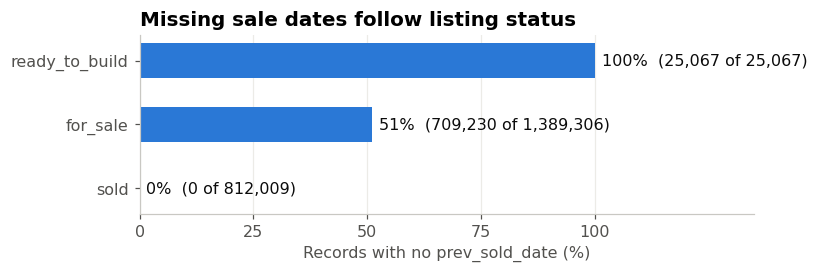

,mean,sum,size
status,,,
sold,0.000000,0,812009
for_sale,0.510492,709230,1389306
ready_to_build,1.000000,25067,25067


In [5]:
miss = raw['prev_sold_date'].isna().groupby(raw['status']).agg(['mean', 'sum', 'size'])
miss = miss.sort_values('mean')
assert miss.loc['sold', 'sum'] == 0 and miss.loc['ready_to_build', 'mean'] == 1.0

fig, ax = plt.subplots(figsize=(7.5, 2.6))
bars = ax.barh(miss.index, miss['mean'] * 100, color=BLUE, height=0.55)
for b, (st, r) in zip(bars, miss.iterrows()):
    ax.text(b.get_width() + 1.5, b.get_y() + b.get_height() / 2,
            f"{r['mean']:.0%}  ({int(r['sum']):,} of {int(r['size']):,})", va='center', color='#0b0b0b')
ax.set_xlim(0, 135); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('Records with no prev_sold_date (%)')
ax.set_title('Missing sale dates follow listing status')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()
miss

## 4. Finding 2 — "same price, different dates" is one property captured twice

Look at which statuses make up each flagged group.

In [6]:
def status_mix(frame):
    return frame.groupby('gid')['status'].agg(lambda s: ' + '.join(sorted(s)))

mix = status_mix(same_price).value_counts()
share_pair = mix.get('for_sale + sold', 0) / mix.sum()
assert share_pair > 0.998
print(f'groups that are exactly one for_sale + one sold record: {share_pair:.2%}')
mix.head(6).to_frame('groups')

groups that are exactly one for_sale + one sold record: 99.89%


,groups
status,
for_sale + sold,57864
for_sale + for_sale,54
for_sale + for_sale + sold,10
for_sale + sold + sold,2


Now the dates. In every pair, the `sold` record carries a date inside a narrow window (Oct 2021 – May 2022, the period
the data was collected), and the `for_sale` record carries an **older** date: the property's previous sale. So the
"time span" the detector measured is just how long the owner held the property, and the identical price is the list
price recorded again as the sold price.

In [7]:
sold_all = df.loc[df.status == 'sold', 'prev_sold_date']
WINDOW = (sold_all.min(), sold_all.max())
print(f'every sold record is dated between {WINDOW[0]:%Y-%m-%d} and {WINDOW[1]:%Y-%m-%d}')

pairs = same_price.pivot_table(index='gid', columns='status', values='prev_sold_date', aggfunc='max').dropna()
in_window = pairs['sold'].between(*WINDOW).mean()
older = (pairs['for_sale'] < pairs['sold']).mean()
holding_years = (pairs['sold'] - pairs['for_sale']).dt.days / 365.25
assert in_window == 1.0 and older > 0.999
print(f'pairs: {len(pairs):,} | sold date in window: {in_window:.1%} | for_sale date is older: {older:.2%}')
print(f'median gap between the two dates: {holding_years.median():.1f} years')

every sold record is dated between 2021-10-18 and 2022-05-06
pairs: 57,876 | sold date in window: 100.0% | for_sale date is older: 99.99%
median gap between the two dates: 8.6 years


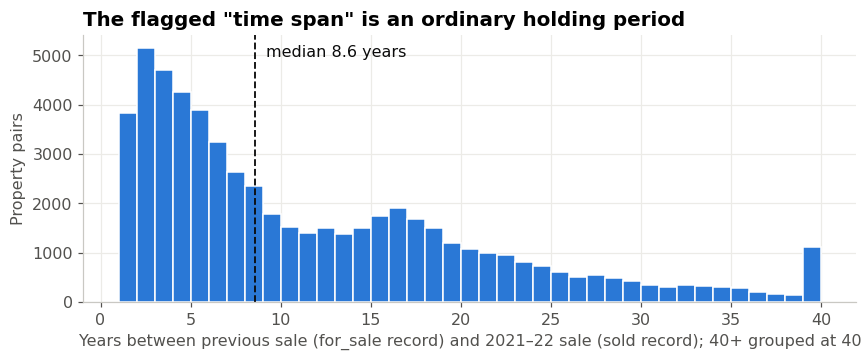

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(holding_years.clip(upper=40), bins=np.arange(1, 41, 1), color=BLUE, edgecolor='white', linewidth=1)
med = holding_years.median()
ax.axvline(med, color='#0b0b0b', lw=1.2, ls='--')
ax.text(med + 0.6, ax.get_ylim()[1] * 0.92, f'median {med:.1f} years', color='#0b0b0b')
ax.set_xlabel('Years between previous sale (for_sale record) and 2021–22 sale (sold record); 40+ grouped at 40')
ax.set_ylabel('Property pairs')
ax.set_title('The flagged "time span" is an ordinary holding period')
plt.tight_layout(); plt.show()

The 365-day threshold also makes the rule arbitrary: the same `for_sale` + `sold` pattern exists for properties
resold within a year, and the detector simply didn't count them. That leads to the next finding.

## 5. Finding 3 — the detector silently skipped records

`df.duplicated()` treats `NaN == NaN`, but `groupby()` drops any group with a missing key value by default. So duplicate
rows with a missing `bed`, `bath`, `house_size`, etc. were found in step one and then lost in step two.

In [9]:
in_dup = df.duplicated(subset=PROPERTY_KEY, keep=False)
dup_all = df[in_dup].assign(gid=lambda d: d.groupby(PROPERTY_KEY, dropna=False).ngroup())
seen = df[in_dup].dropna(subset=PROPERTY_KEY)
print(f'records in a duplicate group           : {in_dup.sum():>9,}  ({in_dup.mean():.1%} of dataset)')
print(f'records the original groupby could see : {len(seen):>9,}')
print(f'silently dropped                        : {in_dup.sum() - len(seen):>9,}')
assert in_dup.sum() == 232_350 and in_dup.sum() - len(seen) == 57_388

mix_all = status_mix(dup_all).value_counts()
print(f"\nall duplicate groups: {mix_all.sum():,}; for_sale + sold pairs: {mix_all['for_sale + sold']:,} "
      f"({mix_all['for_sale + sold'] / mix_all.sum():.1%})")
mix_all.head(6).to_frame('groups')

records in a duplicate group           :   232,350  (10.4% of dataset)
records the original groupby could see :   174,962
silently dropped                        :    57,388



all duplicate groups: 116,107; for_sale + sold pairs: 115,382 (99.4%)


,groups
status,
for_sale + sold,115382
for_sale + for_sale,572
for_sale + for_sale + sold,49
sold + sold,47
for_sale + sold + sold,26
for_sale + for_sale + for_sale,10


## 6. Finding 4 — the "price manipulation" detector finds the same pairs

In [10]:
mix_m = status_mix(manipulation).value_counts()
share_m = mix_m['for_sale + sold'] / mix_m.sum()
assert share_m > 0.998
print(f'"price manipulation" properties that are a for_sale + sold pair: {share_m:.2%}')
overlap = manipulation.index.isin(same_price.index).mean()
print(f'records also flagged by the same-price detector: {overlap:.1%}')

"price manipulation" properties that are a for_sale + sold pair: 99.85%
records also flagged by the same-price detector: 86.5%


## 7. Finding 5 — "suspicious brokers" are the biggest brokers

If flags came from misconduct, some brokers would be flagged far more often than their volume predicts. If they come
from the scraping process, flags should scale with how many sales a broker has. They scale with sales.

In [11]:
flag_per_broker = same_price.groupby('gid')['brokered_by'].first().value_counts()
sold_per_broker = df[df.status == 'sold']['brokered_by'].value_counts()
listings_per_broker = df['brokered_by'].value_counts()
b = pd.concat([flag_per_broker.rename('flagged_pairs'), sold_per_broker.rename('sold_listings'),
               listings_per_broker.rename('all_listings')], axis=1).fillna(0)
b = b[b.flagged_pairs > 0]
rho = spearmanr(b.flagged_pairs, b.sold_listings).statistic
b['flags_per_sale'] = b.flagged_pairs / b.sold_listings.replace(0, np.nan)
top = b.sort_values('flagged_pairs', ascending=False).head(3)
assert list(top.index) == list(listings_per_broker.index[:3])  # top-flagged == top by volume
print(f'Spearman rho (flagged pairs vs sold listings), {len(b):,} brokers: {rho:.2f}')
top.astype({'flagged_pairs': int, 'sold_listings': int, 'all_listings': int}).round(3)

Spearman rho (flagged pairs vs sold listings), 16,205 brokers: 0.71


,flagged_pairs,sold_listings,all_listings,flags_per_sale
brokered_by,,,,
22611.0,1854,21310,45658,0.087
16829.0,1207,14521,27732,0.083
53016.0,865,10150,21709,0.085


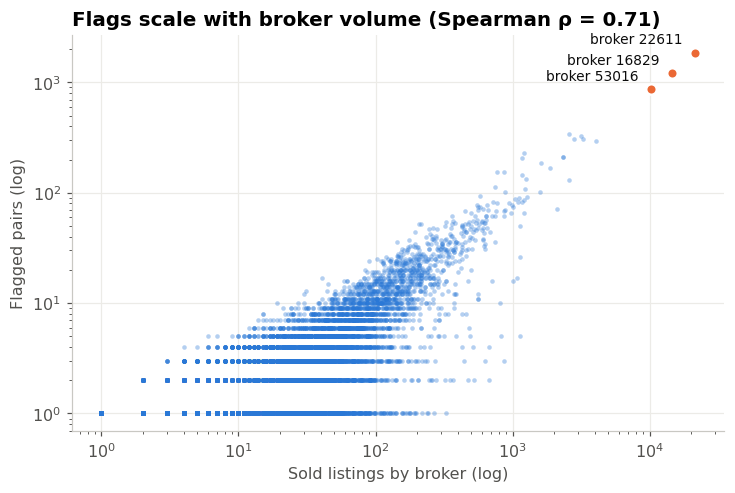

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.scatter(b.sold_listings.clip(lower=1), b.flagged_pairs, s=9, color=BLUE, alpha=0.35, linewidths=0)
for bid, r in top.iterrows():
    ax.scatter(r.sold_listings, r.flagged_pairs, s=46, color=ORANGE, edgecolor='white', linewidth=1.5, zorder=3)
    ax.annotate(f'broker {int(bid)}', (r.sold_listings, r.flagged_pairs), xytext=(-8, 6),
                textcoords='offset points', ha='right', color='#0b0b0b', fontsize=9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Sold listings by broker (log)'); ax.set_ylabel('Flagged pairs (log)')
ax.set_title(f'Flags scale with broker volume (Spearman ρ = {rho:.2f})')
plt.tight_layout(); plt.show()

## 8. What is genuinely worth reviewing

Removing the artefacts doesn't mean the data is clean. These remain, and later parts of the series test detectors for
them properly (with planted errors and measured precision/recall):

In [13]:
same_status = mix_all[[k for k in mix_all.index if 'sold' not in k or 'for_sale' not in k]]
unparseable = raw.loc[raw.prev_sold_date.notna() & df.prev_sold_date.isna(), 'prev_sold_date'].tolist()
review = pd.Series({
    'property-level duplicates (for_sale + sold of the same property)': f"{mix_all['for_sale + sold']:,} groups",
    'same-status duplicates (e.g. for_sale + for_sale)': f'{same_status.sum():,} groups',
    'unparseable sale dates': f'{len(unparseable)} {unparseable}',
    'sale dates before 1950': f"{(df.prev_sold_date < '1950-01-01').sum()}",
    'for_sale records whose previous sale is after the collection window': f"{(df.prev_sold_date > WINDOW[1]).sum():,}",
}, name='count')
review.to_frame()

,count
property-level duplicates (for_sale + sold of the same property),"115,382 groups"
same-status duplicates (e.g. for_sale + for_sale),644 groups
unparseable sale dates,1 ['3019-04-02']
sale dates before 1950,13
for_sale records whose previous sale is after the collection window,"12,016"


## 9. Corrected numbers

| Category | Original label | Records | Share | Interpretation |
|---|---|---:|---:|---|
| No previous sale date | "Placeholder date" | 734,297 | 33.0% | Expected missingness; not an anomaly |
| Property captured as `for_sale` and `sold` | "Same price, different dates" (partly) | 230,764 | 10.4% | Duplicate *property*, valid records — dedupe before property-level analysis |
| Same-status duplicates | — | see §8 | <0.1% | Probable true duplicates |
| Implausible dates | — | see §8 | <0.01% | Entry errors to fix or null |

**Lessons for the rest of the series**

1. *Check what a sentinel list matches.* In pandas 2, `astype(str)` on a column with missing values creates the
   string `'nan'`. (pandas 3 changed this behaviour, which is a reason to never rely on it.)
2. *Missing keys and `groupby`:* pass `dropna=False` or handle missing keys explicitly; otherwise records vanish silently.
3. *Explain a pattern before labelling it.* A rule that flags 5% of a market as "possible fraud" should be checked
   against the data-generating process (here: a scraper capturing listings at two lifecycle stages) and against a
   volume baseline.
4. *Validate detectors on data with known answers.* Part 2 plants synthetic errors and measures precision and recall.

In [14]:
lifecycle_rows = dup_all.groupby('gid')['status'].transform(lambda s: ' + '.join(sorted(s))) == 'for_sale + sold'
print(f'records in for_sale + sold property pairs: {lifecycle_rows.sum():,} ({lifecycle_rows.sum() / N:.1%})')
assert lifecycle_rows.sum() == 230_764

records in for_sale + sold property pairs: 230,764 (10.4%)
